## STEP 0 — Setup

In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("MoviesOnStreamingPlatforms.csv")

In [2]:
df.head()

,Unnamed: 0,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type
0,0,1,The Irishman,2019,18+,98/100,1,0,0,0,0
1,1,2,Dangal,2016,7+,97/100,1,0,0,0,0
2,2,3,David Attenborough: A Life on Our Planet,2020,7+,95/100,1,0,0,0,0
3,3,4,Lagaan: Once Upon a Time in India,2001,7+,94/100,1,0,0,0,0
4,4,5,Roma,2018,18+,94/100,1,0,0,0,0


## STEP 0.1 — Understand the dataset

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9515 entries, 0 to 9514
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Unnamed: 0       9515 non-null   int64
 1   ID               9515 non-null   int64
 2   Title            9515 non-null   str  
 3   Year             9515 non-null   int64
 4   Age              5338 non-null   str  
 5   Rotten Tomatoes  9508 non-null   str  
 6   Netflix          9515 non-null   int64
 7   Hulu             9515 non-null   int64
 8   Prime Video      9515 non-null   int64
 9   Disney+          9515 non-null   int64
 10  Type             9515 non-null   int64
dtypes: int64(8), str(3)
memory usage: 1.0 MB


In [4]:
df.describe()       #this gives us statistical information about numeric columns

,Unnamed: 0,ID,Year,Netflix,Hulu,Prime Video,Disney+,Type
count,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.0
mean,4757.000000,4758.000000,2007.422386,0.388334,0.110037,0.432265,0.096900,0.0
std,2746.888239,2746.888239,19.130367,0.487397,0.312952,0.495417,0.295837,0.0
min,0.000000,1.000000,1914.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,2378.500000,2379.500000,2006.000000,0.000000,0.000000,0.000000,0.000000,0.0
50%,4757.000000,4758.000000,2015.000000,0.000000,0.000000,0.000000,0.000000,0.0
75%,7135.500000,7136.500000,2018.000000,1.000000,0.000000,1.000000,0.000000,0.0
max,9514.000000,9515.000000,2021.000000,1.000000,1.000000,1.000000,1.000000,0.0


## STEP 0.2 — Clean Rotten Tomatoes

In [ ]:
df['Rotten Tomatoes Score'] = (
    df['Rotten Tomatoes']
    .str.replace('/100', '', regex=False)
    .astype(float)
)                                              #convert the text value into numeric value

In [6]:
df[['Rotten Tomatoes', 'Rotten Tomatoes Score']].head()

,Rotten Tomatoes,Rotten Tomatoes Score
0,98/100,98.0
1,97/100,97.0
2,95/100,95.0
3,94/100,94.0
4,94/100,94.0


## STEP 0.3 — Check the cleaned column

In [ ]:
df['Rotten Tomatoes Score'].describe()     # select only the rotten tomatoes score columns and then calculate its statistical summary

count    9508.000000
mean       53.545015
std        13.197673
min        10.000000
25%        44.000000
50%        52.000000
75%        62.000000
max        98.000000
Name: Rotten Tomatoes Score, dtype: float64

In [8]:
df['Rotten Tomatoes Score'].isna().sum() #checks the missing values too

np.int64(7)

## STEP 1 — Boxplot Using Seaborn

STEP 1.1 — Remove missing Age values

In [9]:
plot_df = df[
    df['Age'].notna() &
    df['Rotten Tomatoes Score'].notna()
]

In [10]:
plot_df['Age'].value_counts()

Age
18+    2276
7+     1090
13+     998
all     698
16+     276
Name: count, dtype: int64

STEP 1.2 — Create the Boxplot

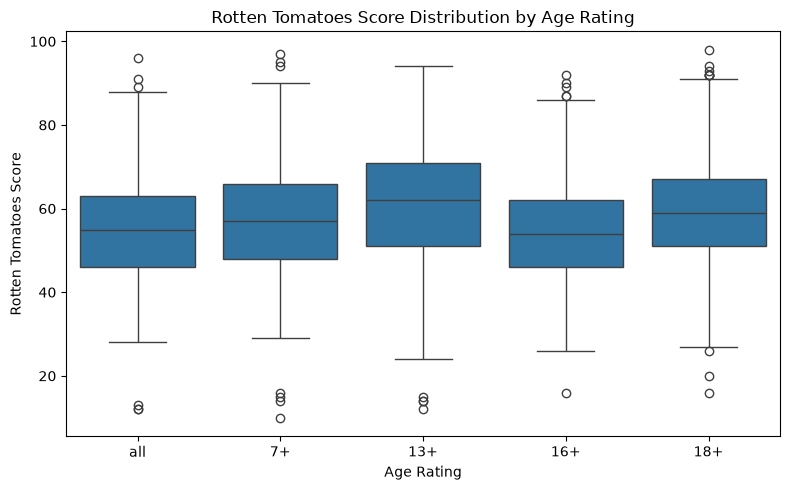

In [ ]:
age_order = ['all', '7+', '13+', '16+', '18+']

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=plot_df,
    x='Age',
    y='Rotten Tomatoes Score',
    order=age_order
)

plt.title('Rotten Tomatoes Score Distribution by Age Rating')
plt.xlabel('Age Rating')
plt.ylabel('Rotten Tomatoes Score')

plt.tight_layout()
plt.show()      #Each box represents the distribution of movie ratings for an age category.
                #Boxplot is used to compare the distribution, median, spread and outliers of Rotten Tomatoes scores across different age ratings.

Step 1.3 - Create a Color Boxplot

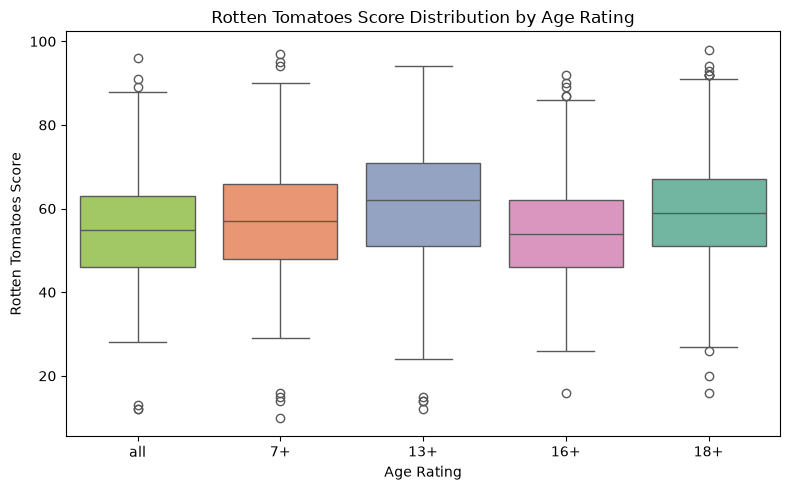

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=plot_df,
    x='Age',
    y='Rotten Tomatoes Score',
    order=age_order,
    palette='Set2',
    hue='Age',
    legend=False
)

plt.title('Rotten Tomatoes Score Distribution by Age Rating')
plt.xlabel('Age Rating')
plt.ylabel('Rotten Tomatoes Score')

plt.tight_layout()
plt.show()

## STEP 2 — Histogram + KDE

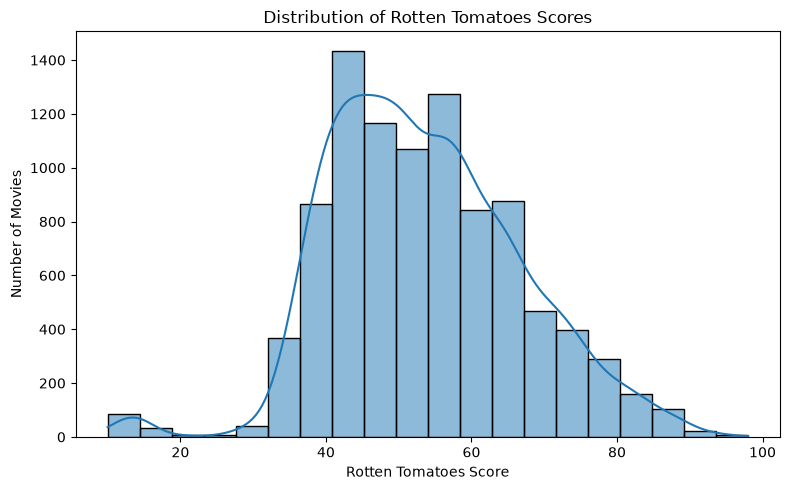

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='Rotten Tomatoes Score',
    kde=True,                #adds a smooth curve showing the overall distribution.
    bins=20                  #divides the rating range into 20 intervals.
)

plt.title('Distribution of Rotten Tomatoes Scores')
plt.xlabel('Rotten Tomatoes Score')
plt.ylabel('Number of Movies')

plt.tight_layout()
plt.show()


#The histogram shows how Rotten Tomatoes scores are distributed among the movies, while KDE provides a smooth representation of the distribution.

## STEP 3 — Correlation Heatmap

In [16]:
nums_cols = [
    'Year',
    'Rotten Tomatoes Score',
    'Netflix',
    'Hulu',
    'Prime Video',
    'Disney+',
    'Type'
]

corr = df[nums_cols].corr()

STEP 3.1 — Create Heatmap

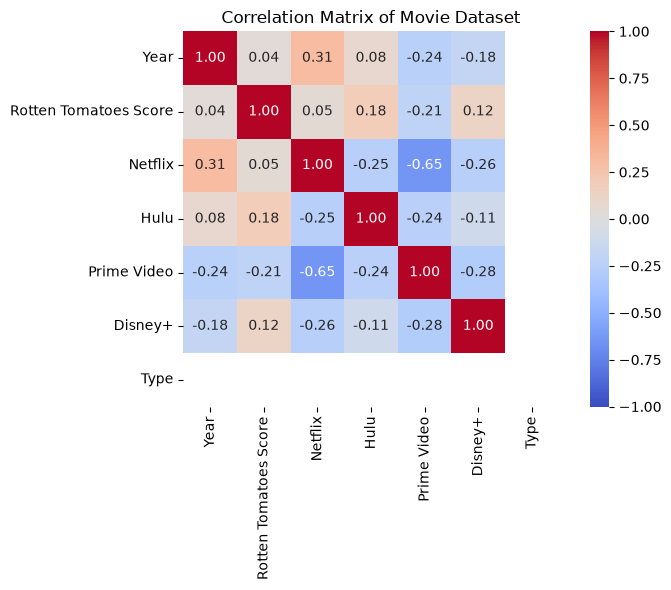

In [17]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt='.2f',
    square=True
)

plt.title('Correlation Matrix of Movie Dataset')

plt.tight_layout()
plt.show()

Correlation values range from:

- -1  ← strong negative relationship
-  0  ← little/no linear relationship
- +1  ← strong positive relationship

For example, if:

- Netflix ↔ Hulu = 0.20

that means there is a weak positive correlation.

If:

- Netflix ↔ Hulu = -0.05

there is almost no linear relationship.

## Step 4 — Violin Plot

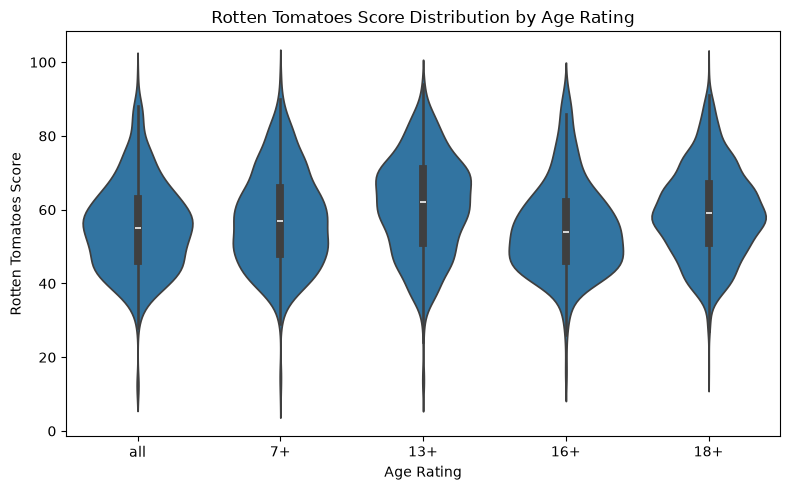

In [ ]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=plot_df,
    x='Age',
    y='Rotten Tomatoes Score',
    order=age_order
)

plt.title('Rotten Tomatoes Score Distribution by Age Rating')
plt.xlabel('Age Rating')
plt.ylabel('Rotten Tomatoes Score')

plt.tight_layout()
plt.show()

#The violin plot shows the distribution/density of Rotten Tomatoes scores for each age rating.

Step 4.1 - Create a Color ViolinPlot

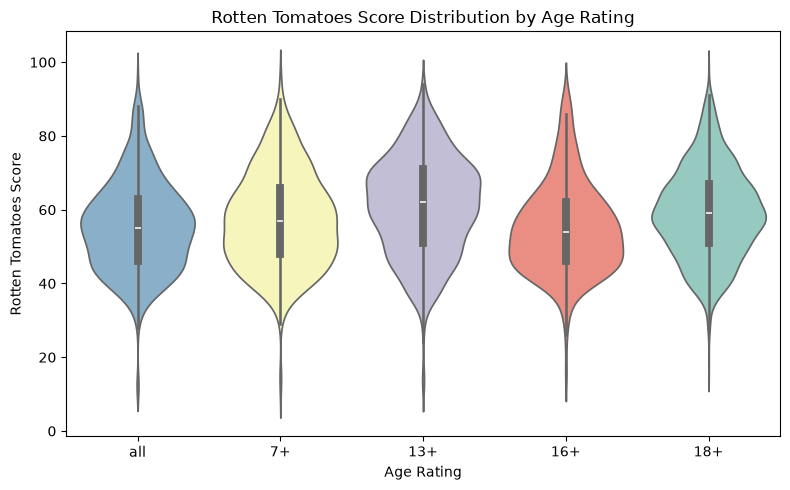

In [24]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=plot_df,
    x='Age',
    y='Rotten Tomatoes Score',
    order=age_order,
    palette='Set3',
    hue='Age',
    legend=False
)

plt.title('Rotten Tomatoes Score Distribution by Age Rating')
plt.xlabel('Age Rating')
plt.ylabel('Rotten Tomatoes Score')

plt.tight_layout()
plt.show()

## STEP 5 — Platform Analysis

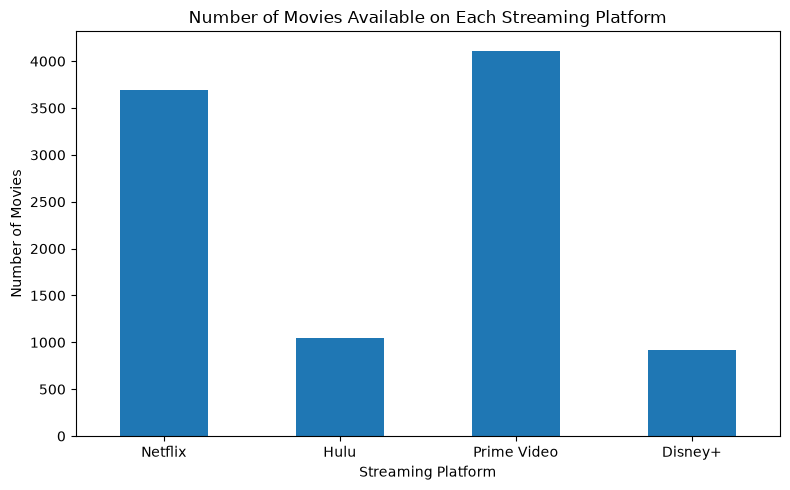

In [19]:
platforms = ['Netflix', 'Hulu', 'Prime Video', 'Disney+']

platform_counts = df[platforms].sum()

plt.figure(figsize=(8, 5))

platform_counts.plot(kind='bar')

plt.title('Number of Movies Available on Each Streaming Platform')
plt.xlabel('Streaming Platform')
plt.ylabel('Number of Movies')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## STEP 6 — Movies by Year

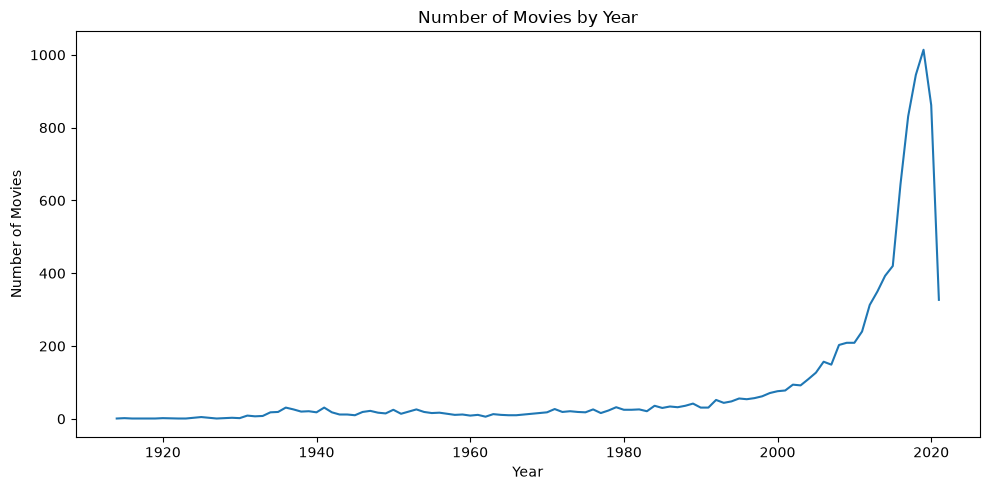

In [20]:
movies_by_year = df['Year'].value_counts().sort_index()

plt.figure(figsize=(10, 5))

plt.plot(
    movies_by_year.index,
    movies_by_year.values
)

plt.title('Number of Movies by Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')

plt.tight_layout()
plt.show()

## CONCLUSION :-



In this lab, I analyzed the `MoviesOnStreamingPlatforms.csv` dataset using Python, Pandas, Matplotlib, and Seaborn. I used different plots such as boxplot, violin plot, histogram, and heatmap to understand the data better. These visualizations helped me study the distribution of Rotten Tomatoes scores, compare scores based on age ratings, and understand the relationships between different numerical columns. Overall, the lab helped me understand how data visualization can be used to find useful patterns and insights from a dataset.
